In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import numpy as np
import rnanorm
import gffutils

In [2]:
arabi_gene_names = pd.read_csv(
    "/Users/michael/Data/Reference_data/Arabdidopsis_empty_reads_per_gene.csv",
    index_col="Gene Name",
)
arabi_gene_names

""
Gene Name
AT1G01010
AT1G01020
AT1G03987
AT1G01030
AT1G01040
...
ArthCt118
ArthCp083
ArthCt111


In [3]:
plate_data_location = "/Users/michael/Data/Luke_terrace_experiment"
plate_list = ["Plate1", "Plate2", "Plate3", "Plate4", "Plate5"]
quality_meta_data = pd.DataFrame(
    columns=[
        "Unmapped",
        "Multimapping",
        "No Feature",
        "Ambiguous Unstranded",
        "Ambiguous Forward",
    ]
)
expression_data = arabi_gene_names

In [4]:
def Luke_file_parser(
    file_name,
    quality_dataframe,
    df_with_gene_names,
    data_directory="/Users/michael/Data",
):
    file_clean = file_name.split(".")[0]
    sample_incl_quality = pd.read_csv(
        f"{data_directory}/{file_name}",
        sep="\t",
        names=["Gene Name", "Unstranded", "Forward", "Reverse"],
    )
    quality_data = sample_incl_quality["Unstranded"][0:4].to_list()
    quality_data.append(sample_incl_quality["Forward"][3].item())
    sample_read_quality_meta_data = pd.DataFrame(
        columns=[
            "Unmapped",
            "Multimapping",
            "No Feature",
            "Ambiguous Unstranded",
            "Ambiguous Forward",
        ],
        data=[quality_data],
        index=[file_clean],
    )
    quality_dataframe = pd.concat([quality_dataframe, sample_read_quality_meta_data])
    cleaned_sample_data = pd.read_csv(
        f"{data_directory}/{file_name}",
        sep="\t",
        names=["Gene Name", "Unstranded", "Forward", "Reverse"],
        skiprows=4,
    )
    df_with_gene_names[file_clean] = cleaned_sample_data["Forward"].to_list()
    return quality_dataframe, df_with_gene_names

In [5]:
for plate in plate_list:
    list_of_files = os.listdir(f"{plate_data_location}/{plate}")
    for file in list_of_files:
        quality_meta_data, expression_data = Luke_file_parser(
            file,
            quality_meta_data,
            expression_data,
            data_directory=f"{plate_data_location}/{plate}",
        )

/var/folders/nk/6xkk9sgn1pz4ff1b36sfq3y40000gt/T/ipykernel_98296/3458216648.py:33: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_with_gene_names[file_clean] = cleaned_sample_data["Forward"].to_list()
/var/folders/nk/6xkk9sgn1pz4ff1b36sfq3y40000gt/T/ipykernel_98296/3458216648.py:33: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_with_gene_names[file_clean] = cleaned_sample_data["Forward"].to_list()
/var/folders/nk/6xkk9sgn1pz4ff1b36sfq3y40000gt/T/ipykernel_98296/3458216648.py:33: PerformanceWarning: DataFrame is highly fragm

In [6]:
quality_meta_data

,Unmapped,Multimapping,No Feature,Ambiguous Unstranded,Ambiguous Forward
A2450525897_n01_LICRNA01_H06,4328244,499905,321262,442619,51564
A2450525897_n01_LICRNA01_F06,4579055,780856,331588,745568,79267
A2450525897_n01_LICRNA01_E01,3004324,309156,135512,229101,26474
A2450525897_n01_LICRNA01_H10,2291624,408948,159867,259492,34365
A2450525897_n01_LICRNA01_F10,1988907,313884,161241,268582,33331
...,...,...,...,...,...
A2534491401_n01_LICRNA05_C02,104383,20968,3315,20659,2257
A2534491401_n01_LICRNA05_E04,2979118,417492,207576,316951,34753
A2534491401_n01_LICRNA05_H12,5438007,945993,647515,873351,100264
A2534491401_n01_LICRNA05_B09,337227,186069,41305,64533,10510


In [7]:
expression_data = expression_data.T

In [8]:
expression_data = expression_data.rename_axis(None, axis=1)
expression_data

,AT1G01010,AT1G01020,AT1G03987,AT1G01030,AT1G01040,AT1G03993,AT1G01046,AT1G01050,AT1G03997,AT1G01060,...,ArthCt124,ArthCr088,ArthCt112,ArthCp088,ArthCp086,ArthCt118,ArthCp083,ArthCt111,ArthCp084,ArthCp085
A2450525897_n01_LICRNA01_H06,0,48,0,34,111,0,0,343,0,198,...,5,53,1,29,0,0,30,0,0,6
A2450525897_n01_LICRNA01_F06,12,87,0,55,150,0,0,331,0,212,...,3,82,5,18,0,0,3,0,0,12
A2450525897_n01_LICRNA01_E01,19,27,0,22,41,0,0,135,0,89,...,0,44,0,0,0,0,3,0,0,5
A2450525897_n01_LICRNA01_H10,6,24,0,5,97,0,0,140,0,75,...,0,32,0,2,0,0,8,0,0,0
A2450525897_n01_LICRNA01_F10,6,42,0,6,85,0,0,215,0,69,...,0,15,0,9,0,0,4,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
A2534491401_n01_LICRNA05_C02,0,0,0,0,0,0,0,20,0,0,...,0,0,0,0,0,0,0,0,0,0
A2534491401_n01_LICRNA05_E04,0,52,0,18,96,0,0,192,0,437,...,0,42,0,0,0,0,0,0,0,37
A2534491401_n01_LICRNA05_H12,15,166,0,96,295,0,0,567,0,1144,...,6,39,12,26,0,0,33,0,0,47
A2534491401_n01_LICRNA05_B09,5,6,0,1,34,0,0,59,0,106,...,0,18,0,0,0,0,1,0,0,0


In [9]:
sample_guide = pd.read_csv(
    "/Users/michael/Git/Outdoor_microbiome/Local_analysis/Converting_plates_to_normal_format/Plates_1_to_5_just_merged.csv",
    index_col=0,
)
sample_guide["filename"] = sample_guide["filename"].str.split(".").str[0]
sample_guide

,filename,plate.pos,arb.sort,sampID,sample.type,timepoint,date,time,extractplate,rnaprepplate
0,A2450525897_n01_LICRNA01_A01,A01,1,LIC001,plant,t01,11/1/23,8:00,LIC_01,LICRNA_01
1,A2450525897_n01_LICRNA01_B01,B01,2,LIC002,plant,t01,11/1/23,8:00,LIC_01,LICRNA_01
2,A2450525897_n01_LICRNA01_C01,C01,3,LIC003,plant,t01,11/1/23,8:00,LIC_01,LICRNA_01
3,A2450525897_n01_LICRNA01_D01,D01,4,LIC004,plant,t01,11/1/23,8:00,LIC_01,LICRNA_01
4,A2450525897_n01_LICRNA01_E01,E01,5,LIC005,plant,t01,11/1/23,8:00,LIC_01,LICRNA_01
...,...,...,...,...,...,...,...,...,...,...
475,A2534491401_n01_LICRNA05_D12,D12,92,LIC542,plant,c1_t13,2/11/24,20:00,LICCIRC_02,LICRNA_05
476,A2534491401_n01_LICRNA05_E12,E12,93,LIC495,plant,c1_t09,2/11/24,4:00,LICCIRC_02,LICRNA_05
477,A2534491401_n01_LICRNA05_F12,F12,94,LIC421,plant,c1_t04,2/10/24,8:00,LICCIRC_01,LICRNA_05
478,A2534491401_n01_LICRNA05_G12,G12,95,LIC493,plant,c1_t09,2/11/24,4:00,LICCIRC_02,LICRNA_05


In [10]:
### Note missing rows from undertermined aka extra background sample run

pd.merge(
    expression_data,
    sample_guide,
    right_on="filename",
    left_index=True,
    how="left",
    indicator=True,
).query('_merge == "left_only"').drop("_merge", axis=1)

,AT1G01010,AT1G01020,AT1G03987,AT1G01030,AT1G01040,AT1G03993,AT1G01046,AT1G01050,AT1G03997,AT1G01060,...,filename,plate.pos,arb.sort,sampID,sample.type,timepoint,date,time,extractplate,rnaprepplate
NaN,37,145,0,75,304,0,2,620,0,732,...,A2450525897_n01_undetermined,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NaN,66,252,0,86,619,0,2,950,0,1229,...,A2449446903_n01_undetermined,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NaN,46,293,0,99,701,0,0,1372,0,1094,...,B250508004_n01_undetermined,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NaN,26,232,0,91,534,0,0,1071,0,771,...,B2449500127_n01_undetermined,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NaN,32,286,0,127,521,0,0,1146,0,973,...,A2534491401_n01_undetermined,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
quality_meta_data

,Unmapped,Multimapping,No Feature,Ambiguous Unstranded,Ambiguous Forward
A2450525897_n01_LICRNA01_H06,4328244,499905,321262,442619,51564
A2450525897_n01_LICRNA01_F06,4579055,780856,331588,745568,79267
A2450525897_n01_LICRNA01_E01,3004324,309156,135512,229101,26474
A2450525897_n01_LICRNA01_H10,2291624,408948,159867,259492,34365
A2450525897_n01_LICRNA01_F10,1988907,313884,161241,268582,33331
...,...,...,...,...,...
A2534491401_n01_LICRNA05_C02,104383,20968,3315,20659,2257
A2534491401_n01_LICRNA05_E04,2979118,417492,207576,316951,34753
A2534491401_n01_LICRNA05_H12,5438007,945993,647515,873351,100264
A2534491401_n01_LICRNA05_B09,337227,186069,41305,64533,10510


In [12]:
sample_guide

,filename,plate.pos,arb.sort,sampID,sample.type,timepoint,date,time,extractplate,rnaprepplate
0,A2450525897_n01_LICRNA01_A01,A01,1,LIC001,plant,t01,11/1/23,8:00,LIC_01,LICRNA_01
1,A2450525897_n01_LICRNA01_B01,B01,2,LIC002,plant,t01,11/1/23,8:00,LIC_01,LICRNA_01
2,A2450525897_n01_LICRNA01_C01,C01,3,LIC003,plant,t01,11/1/23,8:00,LIC_01,LICRNA_01
3,A2450525897_n01_LICRNA01_D01,D01,4,LIC004,plant,t01,11/1/23,8:00,LIC_01,LICRNA_01
4,A2450525897_n01_LICRNA01_E01,E01,5,LIC005,plant,t01,11/1/23,8:00,LIC_01,LICRNA_01
...,...,...,...,...,...,...,...,...,...,...
475,A2534491401_n01_LICRNA05_D12,D12,92,LIC542,plant,c1_t13,2/11/24,20:00,LICCIRC_02,LICRNA_05
476,A2534491401_n01_LICRNA05_E12,E12,93,LIC495,plant,c1_t09,2/11/24,4:00,LICCIRC_02,LICRNA_05
477,A2534491401_n01_LICRNA05_F12,F12,94,LIC421,plant,c1_t04,2/10/24,8:00,LICCIRC_01,LICRNA_05
478,A2534491401_n01_LICRNA05_G12,G12,95,LIC493,plant,c1_t09,2/11/24,4:00,LICCIRC_02,LICRNA_05


In [13]:
full_meta_data = sample_guide.merge(
    quality_meta_data, left_on="filename", right_index=True
)
full_meta_data["plate_row"] = full_meta_data["plate.pos"].str[0]
full_meta_data["plate_col"] = full_meta_data["plate.pos"].str[1:].astype(int)
total_reads_plate = expression_data.sum(axis=1)
total_reads_plate.name = "Total Reads"
full_meta_data = full_meta_data.merge(
    total_reads_plate, left_on="filename", right_index=True
)

In [14]:
full_meta_data

,filename,plate.pos,arb.sort,sampID,sample.type,timepoint,date,time,extractplate,rnaprepplate,Unmapped,Multimapping,No Feature,Ambiguous Unstranded,Ambiguous Forward,plate_row,plate_col,Total Reads
0,A2450525897_n01_LICRNA01_A01,A01,1,LIC001,plant,t01,11/1/23,8:00,LIC_01,LICRNA_01,2633048,334817,112554,202285,22008,A,1,2248661
1,A2450525897_n01_LICRNA01_B01,B01,2,LIC002,plant,t01,11/1/23,8:00,LIC_01,LICRNA_01,5074184,776239,226718,494847,49830,B,1,5984566
2,A2450525897_n01_LICRNA01_C01,C01,3,LIC003,plant,t01,11/1/23,8:00,LIC_01,LICRNA_01,2283008,427910,97848,271449,28416,C,1,2936453
3,A2450525897_n01_LICRNA01_D01,D01,4,LIC004,plant,t01,11/1/23,8:00,LIC_01,LICRNA_01,1263467,177674,49095,123691,13452,D,1,1359823
4,A2450525897_n01_LICRNA01_E01,E01,5,LIC005,plant,t01,11/1/23,8:00,LIC_01,LICRNA_01,3004324,309156,135512,229101,26474,E,1,2680737
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
475,A2534491401_n01_LICRNA05_D12,D12,92,LIC542,plant,c1_t13,2/11/24,20:00,LICCIRC_02,LICRNA_05,4303811,813353,383610,550523,68933,D,12,6510475
476,A2534491401_n01_LICRNA05_E12,E12,93,LIC495,plant,c1_t09,2/11/24,4:00,LICCIRC_02,LICRNA_05,4231836,923444,451686,560171,67290,E,12,6178604
477,A2534491401_n01_LICRNA05_F12,F12,94,LIC421,plant,c1_t04,2/10/24,8:00,LICCIRC_01,LICRNA_05,4885375,877561,360911,638643,80102,F,12,7035335
478,A2534491401_n01_LICRNA05_G12,G12,95,LIC493,plant,c1_t09,2/11/24,4:00,LICCIRC_02,LICRNA_05,6078838,931512,518084,1005149,113565,G,12,11812634


In [15]:
full_meta_data = full_meta_data.replace(0, np.nan)
full_meta_data["Unmapped Over Mapped"] = (
    full_meta_data["Unmapped"] / full_meta_data["Total Reads"]
)

/var/folders/nk/6xkk9sgn1pz4ff1b36sfq3y40000gt/T/ipykernel_98296/2878017952.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  full_meta_data = full_meta_data.replace(0, np.nan)


In [16]:
full_meta_data

,filename,plate.pos,arb.sort,sampID,sample.type,timepoint,date,time,extractplate,rnaprepplate,Unmapped,Multimapping,No Feature,Ambiguous Unstranded,Ambiguous Forward,plate_row,plate_col,Total Reads,Unmapped Over Mapped
0,A2450525897_n01_LICRNA01_A01,A01,1,LIC001,plant,t01,11/1/23,8:00,LIC_01,LICRNA_01,2633048.0,334817.0,112554.0,202285.0,22008.0,A,1,2248661.0,1.170940
1,A2450525897_n01_LICRNA01_B01,B01,2,LIC002,plant,t01,11/1/23,8:00,LIC_01,LICRNA_01,5074184.0,776239.0,226718.0,494847.0,49830.0,B,1,5984566.0,0.847878
2,A2450525897_n01_LICRNA01_C01,C01,3,LIC003,plant,t01,11/1/23,8:00,LIC_01,LICRNA_01,2283008.0,427910.0,97848.0,271449.0,28416.0,C,1,2936453.0,0.777471
3,A2450525897_n01_LICRNA01_D01,D01,4,LIC004,plant,t01,11/1/23,8:00,LIC_01,LICRNA_01,1263467.0,177674.0,49095.0,123691.0,13452.0,D,1,1359823.0,0.929141
4,A2450525897_n01_LICRNA01_E01,E01,5,LIC005,plant,t01,11/1/23,8:00,LIC_01,LICRNA_01,3004324.0,309156.0,135512.0,229101.0,26474.0,E,1,2680737.0,1.120708
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
475,A2534491401_n01_LICRNA05_D12,D12,92,LIC542,plant,c1_t13,2/11/24,20:00,LICCIRC_02,LICRNA_05,4303811.0,813353.0,383610.0,550523.0,68933.0,D,12,6510475.0,0.661059
476,A2534491401_n01_LICRNA05_E12,E12,93,LIC495,plant,c1_t09,2/11/24,4:00,LICCIRC_02,LICRNA_05,4231836.0,923444.0,451686.0,560171.0,67290.0,E,12,6178604.0,0.684918
477,A2534491401_n01_LICRNA05_F12,F12,94,LIC421,plant,c1_t04,2/10/24,8:00,LICCIRC_01,LICRNA_05,4885375.0,877561.0,360911.0,638643.0,80102.0,F,12,7035335.0,0.694405
478,A2534491401_n01_LICRNA05_G12,G12,95,LIC493,plant,c1_t09,2/11/24,4:00,LICCIRC_02,LICRNA_05,6078838.0,931512.0,518084.0,1005149.0,113565.0,G,12,11812634.0,0.514605


In [17]:
# full_meta_data.to_csv(
#     "/Users/michael/Git/Outdoor_microbiome/Local_analysis/Plates_1_to_5_metadata.csv",
#     index=False,
# )

In [18]:
meta_data_heatmap_format_plate_3 = full_meta_data.loc[
    full_meta_data["rnaprepplate"] == "LICRNA_03"
].pivot(index="plate_row", columns="plate_col", values="Total Reads")
meta_data_heatmap_format_plate_3

plate_col,1,2,3,4,5,6,7,8,9,10,11,12
plate_row,,,,,,,,,,,,
A,4702045.0,3426209.0,4993417.0,7992730.0,1966537.0,2110494.0,11274815.0,35127.0,999244.0,11486889.0,7080205.0,8111911.0
B,5527036.0,5844548.0,1227640.0,8735665.0,6397701.0,7028856.0,6850856.0,8760584.0,4984632.0,8262573.0,5975492.0,1930400.0
C,6866480.0,8956360.0,24284117.0,4521223.0,7034134.0,7972493.0,6864049.0,12527244.0,6276767.0,4271077.0,22087076.0,3624627.0
D,4740120.0,10611875.0,13887059.0,7492987.0,5076681.0,3966065.0,2158116.0,12372642.0,19089014.0,1827340.0,14457644.0,6660622.0
E,8146575.0,6880786.0,1467003.0,5576195.0,6382330.0,5222244.0,4353030.0,6279051.0,5527206.0,12524876.0,2408154.0,6665972.0
F,5171208.0,8294003.0,8399773.0,7678391.0,4326439.0,5265097.0,10160371.0,4262375.0,10341989.0,6317980.0,2197530.0,1278970.0
G,8957746.0,4254416.0,3627980.0,2732871.0,4860915.0,4603168.0,2021741.0,7872114.0,3523197.0,9619746.0,6315886.0,4191023.0
H,9338754.0,717003.0,4705779.0,6250771.0,1647357.0,4494472.0,4134513.0,5245242.0,7715482.0,643786.0,1509679.0,5444101.0


Text(83.22222222222221, 0.5, 'Plate Row')

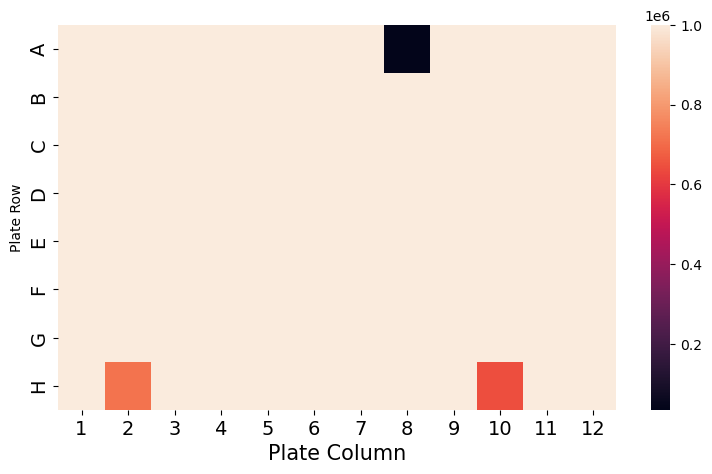

In [19]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(meta_data_heatmap_format_plate_3.astype(float), vmax=1_000_000)
ax.tick_params(axis="x", labelsize=14)
ax.tick_params(axis="y", labelsize=14)
plt.xlabel("Plate Column", fontsize=15)
plt.ylabel("Plate Row")

Text(83.22222222222221, 0.5, 'Plate Row')

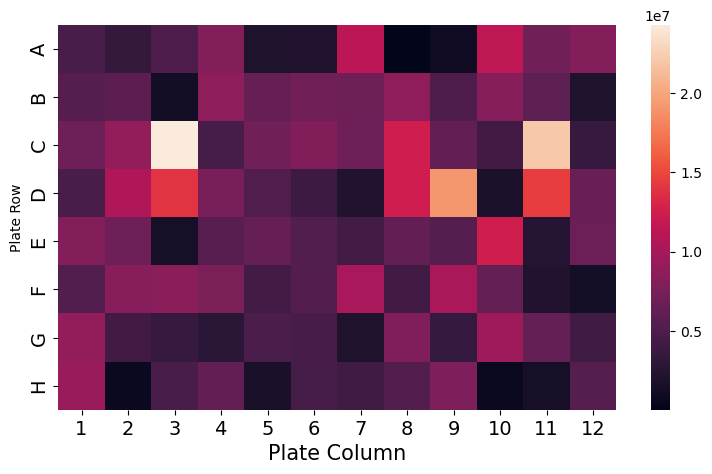

In [20]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(
    meta_data_heatmap_format_plate_3.astype(float),
)
ax.tick_params(axis="x", labelsize=14)
ax.tick_params(axis="y", labelsize=14)
plt.xlabel("Plate Column", fontsize=15)
plt.ylabel("Plate Row")

In [21]:
meta_data_heatmap_format_plate_4 = full_meta_data.loc[
    full_meta_data["rnaprepplate"] == "LICRNA_05"
].pivot(index="plate_row", columns="plate_col", values="Total Reads")

Text(83.22222222222221, 0.5, 'Plate Row')

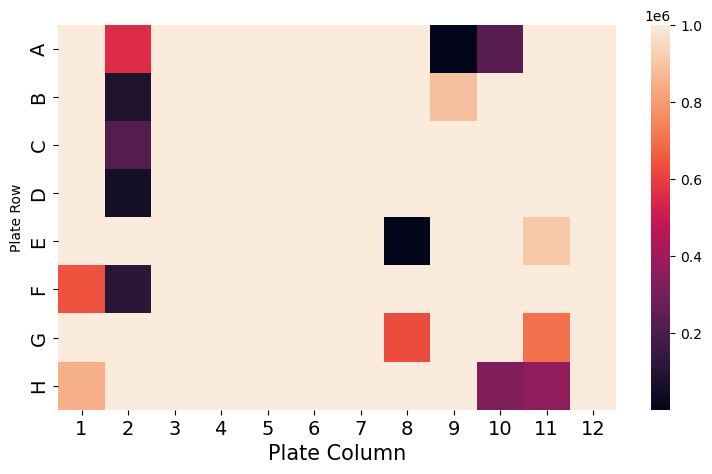

In [22]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(meta_data_heatmap_format_plate_4.astype(float), vmax=1_000_000)
ax.tick_params(axis="x", labelsize=14)
ax.tick_params(axis="y", labelsize=14)
plt.xlabel("Plate Column", fontsize=15)
plt.ylabel("Plate Row")

Text(83.22222222222221, 0.5, 'Plate Row')

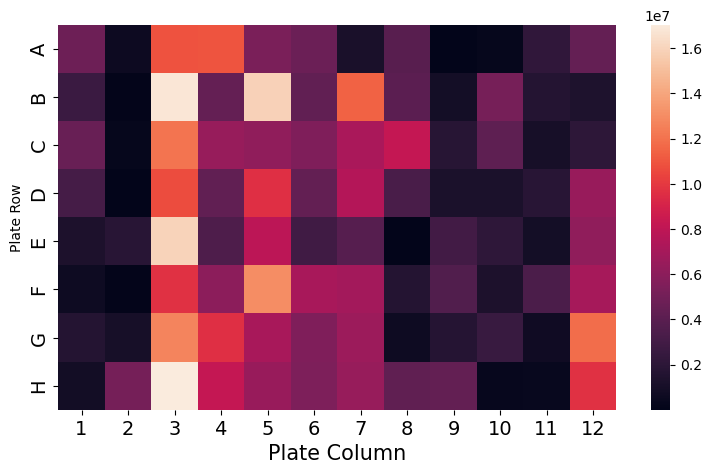

In [23]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(
    meta_data_heatmap_format_plate_4.astype(float),
)
ax.tick_params(axis="x", labelsize=14)
ax.tick_params(axis="y", labelsize=14)
plt.xlabel("Plate Column", fontsize=15)
plt.ylabel("Plate Row")

In [24]:
full_meta_data

,filename,plate.pos,arb.sort,sampID,sample.type,timepoint,date,time,extractplate,rnaprepplate,Unmapped,Multimapping,No Feature,Ambiguous Unstranded,Ambiguous Forward,plate_row,plate_col,Total Reads,Unmapped Over Mapped
0,A2450525897_n01_LICRNA01_A01,A01,1,LIC001,plant,t01,11/1/23,8:00,LIC_01,LICRNA_01,2633048.0,334817.0,112554.0,202285.0,22008.0,A,1,2248661.0,1.170940
1,A2450525897_n01_LICRNA01_B01,B01,2,LIC002,plant,t01,11/1/23,8:00,LIC_01,LICRNA_01,5074184.0,776239.0,226718.0,494847.0,49830.0,B,1,5984566.0,0.847878
2,A2450525897_n01_LICRNA01_C01,C01,3,LIC003,plant,t01,11/1/23,8:00,LIC_01,LICRNA_01,2283008.0,427910.0,97848.0,271449.0,28416.0,C,1,2936453.0,0.777471
3,A2450525897_n01_LICRNA01_D01,D01,4,LIC004,plant,t01,11/1/23,8:00,LIC_01,LICRNA_01,1263467.0,177674.0,49095.0,123691.0,13452.0,D,1,1359823.0,0.929141
4,A2450525897_n01_LICRNA01_E01,E01,5,LIC005,plant,t01,11/1/23,8:00,LIC_01,LICRNA_01,3004324.0,309156.0,135512.0,229101.0,26474.0,E,1,2680737.0,1.120708
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
475,A2534491401_n01_LICRNA05_D12,D12,92,LIC542,plant,c1_t13,2/11/24,20:00,LICCIRC_02,LICRNA_05,4303811.0,813353.0,383610.0,550523.0,68933.0,D,12,6510475.0,0.661059
476,A2534491401_n01_LICRNA05_E12,E12,93,LIC495,plant,c1_t09,2/11/24,4:00,LICCIRC_02,LICRNA_05,4231836.0,923444.0,451686.0,560171.0,67290.0,E,12,6178604.0,0.684918
477,A2534491401_n01_LICRNA05_F12,F12,94,LIC421,plant,c1_t04,2/10/24,8:00,LICCIRC_01,LICRNA_05,4885375.0,877561.0,360911.0,638643.0,80102.0,F,12,7035335.0,0.694405
478,A2534491401_n01_LICRNA05_G12,G12,95,LIC493,plant,c1_t09,2/11/24,4:00,LICCIRC_02,LICRNA_05,6078838.0,931512.0,518084.0,1005149.0,113565.0,G,12,11812634.0,0.514605


Text(83.22222222222221, 0.5, 'Plate Row')

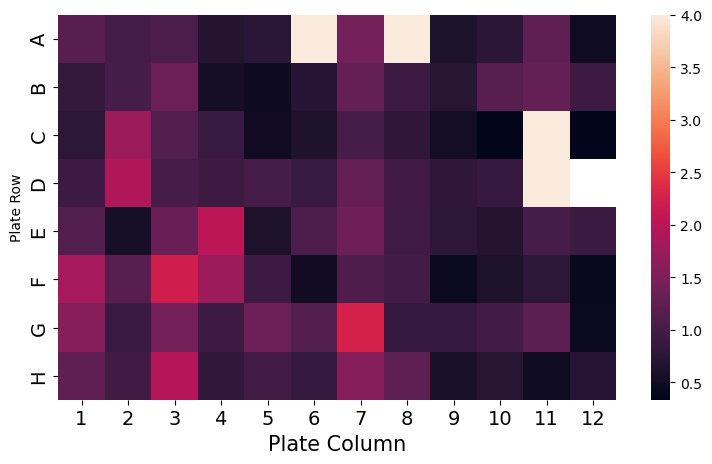

In [25]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(
    full_meta_data.loc[full_meta_data["rnaprepplate"] == "LICRNA_01"]
    .pivot(index="plate_row", columns="plate_col", values="Unmapped Over Mapped")
    .astype(float),
    vmax=4,
)
ax.tick_params(axis="x", labelsize=14)
ax.tick_params(axis="y", labelsize=14)
plt.xlabel("Plate Column", fontsize=15)
plt.ylabel("Plate Row")

Text(83.22222222222221, 0.5, 'Plate Row')

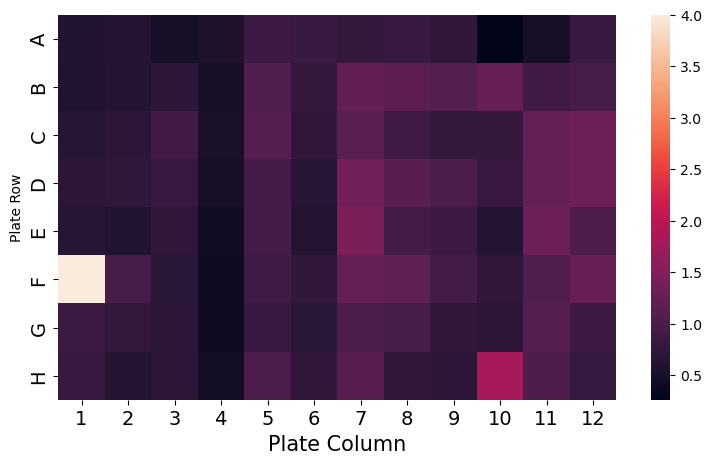

In [26]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(
    full_meta_data.loc[full_meta_data["rnaprepplate"] == "LICRNA_02"]
    .pivot(index="plate_row", columns="plate_col", values="Unmapped Over Mapped")
    .astype(float),
    vmax=4,
)
ax.tick_params(axis="x", labelsize=14)
ax.tick_params(axis="y", labelsize=14)
plt.xlabel("Plate Column", fontsize=15)
plt.ylabel("Plate Row")

Text(83.22222222222221, 0.5, 'Plate Row')

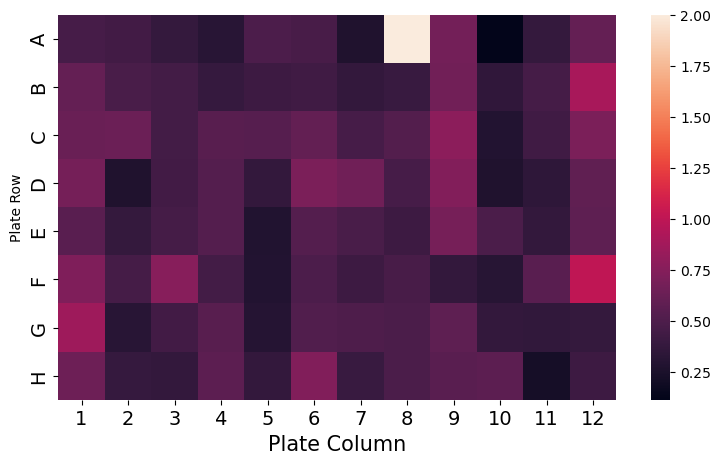

In [27]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(
    full_meta_data.loc[full_meta_data["rnaprepplate"] == "LICRNA_03"]
    .pivot(index="plate_row", columns="plate_col", values="Unmapped Over Mapped")
    .astype(float),
    vmax=2,
)
ax.tick_params(axis="x", labelsize=14)
ax.tick_params(axis="y", labelsize=14)
plt.xlabel("Plate Column", fontsize=15)
plt.ylabel("Plate Row")

Text(83.22222222222221, 0.5, 'Plate Row')

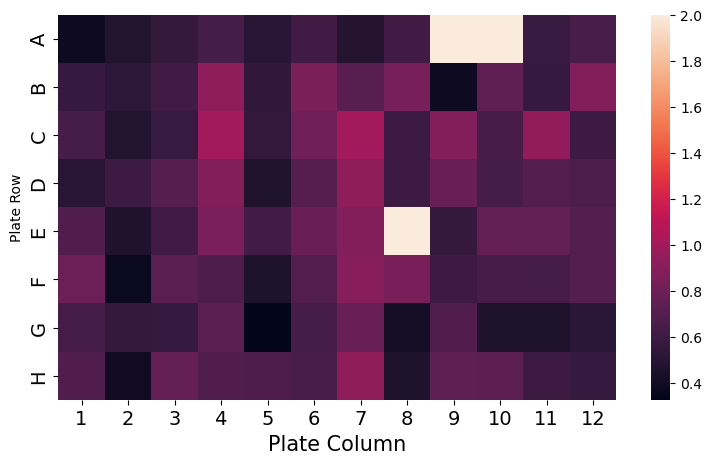

In [28]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(
    full_meta_data.loc[full_meta_data["rnaprepplate"] == "LICRNA_05"]
    .pivot(index="plate_row", columns="plate_col", values="Unmapped Over Mapped")
    .astype(float),
    vmax=2,
)
ax.tick_params(axis="x", labelsize=14)
ax.tick_params(axis="y", labelsize=14)
plt.xlabel("Plate Column", fontsize=15)
plt.ylabel("Plate Row")

In [29]:
expression_data.to_csv('/Users/michael/Data/Luke_terrace_experiment/General_data/plate1_5_for_norm.csv')

In [30]:
expression_data

,AT1G01010,AT1G01020,AT1G03987,AT1G01030,AT1G01040,AT1G03993,AT1G01046,AT1G01050,AT1G03997,AT1G01060,...,ArthCt124,ArthCr088,ArthCt112,ArthCp088,ArthCp086,ArthCt118,ArthCp083,ArthCt111,ArthCp084,ArthCp085
A2450525897_n01_LICRNA01_H06,0,48,0,34,111,0,0,343,0,198,...,5,53,1,29,0,0,30,0,0,6
A2450525897_n01_LICRNA01_F06,12,87,0,55,150,0,0,331,0,212,...,3,82,5,18,0,0,3,0,0,12
A2450525897_n01_LICRNA01_E01,19,27,0,22,41,0,0,135,0,89,...,0,44,0,0,0,0,3,0,0,5
A2450525897_n01_LICRNA01_H10,6,24,0,5,97,0,0,140,0,75,...,0,32,0,2,0,0,8,0,0,0
A2450525897_n01_LICRNA01_F10,6,42,0,6,85,0,0,215,0,69,...,0,15,0,9,0,0,4,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
A2534491401_n01_LICRNA05_C02,0,0,0,0,0,0,0,20,0,0,...,0,0,0,0,0,0,0,0,0,0
A2534491401_n01_LICRNA05_E04,0,52,0,18,96,0,0,192,0,437,...,0,42,0,0,0,0,0,0,0,37
A2534491401_n01_LICRNA05_H12,15,166,0,96,295,0,0,567,0,1144,...,6,39,12,26,0,0,33,0,0,47
A2534491401_n01_LICRNA05_B09,5,6,0,1,34,0,0,59,0,106,...,0,18,0,0,0,0,1,0,0,0


In [37]:
expression_data_trimmed = expression_data.iloc[:, 0:5]

In [38]:
expression_data_trimmed = expression_data_trimmed.reset_index(drop=True)
expression_data_trimmed = expression_data_trimmed.iloc[0:3, :]
expression_data_trimmed

,AT1G01010,AT1G01020,AT1G03987,AT1G01030,AT1G01040
0,0,48,0,34,111
1,12,87,0,55,150
2,19,27,0,22,41


In [39]:
tpm = rnanorm.TPM(
    gtf="/Users/michael/Data/Genomes/Arabidopsis_thaliana/dupe_removed_normal.gtf"
).set_output(transform="pandas")

In [40]:
db = gffutils.create_db(
    "/Users/michael/Data/Genomes/Arabidopsis_thaliana/arabidopsis.gtf",
    "/Users/michael/Data/Genomes/Arabidopsis_thaliana/arabidopsis_gtf_database_merge.db",
    disable_infer_genes=True,
    disable_infer_transcripts=True,
    merge_strategy="merge",
)

KeyboardInterrupt: 

In [ ]:
db = gffutils.FeatureDB(
    "/Users/michael/Data/Genomes/Arabidopsis_thaliana/arabidopsis_gtf_database_merge.db"
)

In [ ]:
with open(
    "/Users/michael/Data/Genomes/Arabidopsis_thaliana/dupe_removed_normal.gtf", "w"
) as fout:
    for f in db.all_features():
        fout.write(str(f) + "\n")

In [ ]:
with open(
    "/Users/michael/Data/Genomes/Arabidopsis_thaliana/dupe_removed_short.gtf", "w"
) as fout:
    for exon in db.features_of_type("exon"):
        genes = [i.id for i in db.parents(exon, featuretype="gene")]
        exon.attributes["gene_id"] = genes
        exon.attributes["length"] = str(len(exon))
        fout.write(str(exon) + "\n")

TypeError: TextIOWrapper.write() takes exactly one argument (2 given)

In [ ]:
db["AT1G01010"]

<Feature gene (NC_003070.9:3631-5899[+]) at 0x18cf74500>

In [ ]:
[f.id for f in db.children("AT1G01010", featuretype="exon")]

['exon_1', 'exon_2', 'exon_3', 'exon_4', 'exon_5', 'exon_6']

In [51]:
expression_data

,AT1G01010,AT1G01020,AT1G03987,AT1G01030,AT1G01040,AT1G03993,AT1G01046,AT1G01050,AT1G03997,AT1G01060,...,ArthCt124,ArthCr088,ArthCt112,ArthCp088,ArthCp086,ArthCt118,ArthCp083,ArthCt111,ArthCp084,ArthCp085
A2450525897_n01_LICRNA01_H06,0,48,0,34,111,0,0,343,0,198,...,5,53,1,29,0,0,30,0,0,6
A2450525897_n01_LICRNA01_F06,12,87,0,55,150,0,0,331,0,212,...,3,82,5,18,0,0,3,0,0,12
A2450525897_n01_LICRNA01_E01,19,27,0,22,41,0,0,135,0,89,...,0,44,0,0,0,0,3,0,0,5
A2450525897_n01_LICRNA01_H10,6,24,0,5,97,0,0,140,0,75,...,0,32,0,2,0,0,8,0,0,0
A2450525897_n01_LICRNA01_F10,6,42,0,6,85,0,0,215,0,69,...,0,15,0,9,0,0,4,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
B2449500127_n01_LICRNA04_H11,6,22,0,1,31,0,0,37,0,45,...,0,17,0,1,0,0,1,0,0,2
B2449500127_n01_LICRNA04_F10,0,25,0,0,74,0,0,178,0,73,...,0,13,0,3,0,0,0,0,0,0
B2449500127_n01_LICRNA04_C01,0,20,0,15,64,0,0,99,0,4,...,0,7,0,5,0,0,1,0,0,20
B2449500127_n01_LICRNA04_D12,15,82,0,11,192,0,0,347,0,116,...,1,47,0,4,0,0,33,0,0,25


In [41]:
tpm_normalized_expression = tpm.fit_transform(expression_data)
tpm_normalized_expression

/Users/michael/miniconda3/envs/rna-norm/lib/python3.12/site-packages/rnanorm/methods/within_sample.py:135: UserWarning: X contains 8 genes that are not in GTF /Users/michael/Data/Genomes/Arabidopsis_thaliana/dupe_removed_normal.gtf. This will result in NaN values for missing genes in the output.
  warnings.warn(
/Users/michael/miniconda3/envs/rna-norm/lib/python3.12/site-packages/rnanorm/methods/within_sample.py:66: RuntimeWarning: invalid value encountered in divide
  return X / lib_size[:, np.newaxis] * 1e6


,AT1G01010,AT1G01020,AT1G03987,AT1G01030,AT1G01040,AT1G03993,AT1G01046,AT1G01050,AT1G03997,AT1G01060,...,ArthCt124,ArthCr088,ArthCt112,ArthCp088,ArthCp086,ArthCt118,ArthCp083,ArthCt111,ArthCp084,ArthCp085
A2450525897_n01_LICRNA01_H06,0.000000,4.710994,0.0,2.751892,2.725712,0.0,0.0,45.395800,0.0,8.924001,...,10.707424,5.480822,2.141485,9.554317,0.0,0.0,0.671838,0.0,0.0,1.121359
A2450525897_n01_LICRNA01_F06,0.708270,5.517386,0.0,2.876458,2.380077,0.0,0.0,28.306904,0.0,6.174092,...,4.151252,5.479318,6.918753,3.831925,0.0,0.0,0.043412,0.0,0.0,1.449164
A2450525897_n01_LICRNA01_E01,3.690795,5.635420,0.0,3.786748,2.141076,0.0,0.0,37.996762,0.0,8.530523,...,0.000000,9.676399,0.000000,0.000000,0.0,0.0,0.142875,0.0,0.0,1.987260
A2450525897_n01_LICRNA01_H10,0.925562,3.977974,0.0,0.683442,4.022612,0.0,0.0,31.291687,0.0,5.708672,...,0.000000,5.588551,0.000000,1.112784,0.0,0.0,0.302561,0.0,0.0,0.000000
A2450525897_n01_LICRNA01_F10,0.894939,6.731127,0.0,0.792996,3.408341,0.0,0.0,46.465133,0.0,5.078210,...,0.000000,2.532960,0.000000,4.841850,0.0,0.0,0.146275,0.0,0.0,0.305183
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
A2534491401_n01_LICRNA05_C02,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0,93.254358,0.0,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.0,0.000000
A2534491401_n01_LICRNA05_E04,0.000000,7.487074,0.0,2.137285,3.458324,0.0,0.0,37.278658,0.0,28.894377,...,0.000000,6.371719,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.0,10.144549
A2534491401_n01_LICRNA05_H12,0.728373,8.660978,0.0,4.130582,3.850938,0.0,0.0,39.892585,0.0,27.409934,...,6.830520,2.143986,13.661041,4.553680,0.0,0.0,0.392867,0.0,0.0,4.669592
A2534491401_n01_LICRNA05_B09,3.004817,3.874320,0.0,0.532507,5.492990,0.0,0.0,51.374367,0.0,31.432085,...,0.000000,12.246592,0.000000,0.000000,0.0,0.0,0.147339,0.0,0.0,0.000000


In [42]:
tpm_normalized_expression.to_csv(
    "/Users/michael/Data/Luke_terrace_experiment/General_data/plate1_5_tpm_normalized.csv"
)